# Adult Income Classification

This notebook modernizes an earlier UCI Adult Income classification project into a focused **applied machine-learning research study**.


### Main capabilities

- reproducible UCI Adult data loading and validation
- leakage-safe preprocessing with `Pipeline` / `ColumnTransformer`
- Logistic Regression, Random Forest, and XGBoost baselines
- stratified cross-validation and XGBoost hyperparameter tuning
- **PyTorch MLP** deep-learning baseline
- **FT-Transformer-style tabular Transformer**
- ROC-AUC, PR-AUC, Precision, Recall, F1, and confusion matrices
- threshold optimization and probability calibration
- MLflow experiment tracking
- statistical Logistic Regression with odds ratios / confidence intervals
- SHAP global and local explainability
- false-positive / false-negative error analysis
- subgroup performance diagnostics
- KS-test and PSI drift / stability analysis
- reproducible model artifacts


We **keep the separate statistical Logistic Regression section** because odds ratios, confidence intervals, and statistical inference demonstrate a genuinely different Data Science skill.

> **Responsible-use note:** this public census dataset is used for research and model evaluation. The model should not be used for consequential decisions about real individuals.

## 1. Colab setup

In [1]:
!pip -q install xgboost shap mlflow statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.

In [2]:
# Standard library
import json
import random
import warnings
import time
from copy import deepcopy
from pathlib import Path

# Data / numerical analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Statistics
from scipy.stats import ks_2samp
import statsmodels.api as sm

# scikit-learn preprocessing
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline

# Model selection and validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# Calibration / importance
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

# Imbalanced learning
# Explainability / tracking
import shap
import mlflow
import mlflow.sklearn

# PyTorch is normally preinstalled in Google Colab.
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

# One seed is reused everywhere so results are reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Environment ready. Device:", DEVICE)

Environment ready. Device: cpu


## 2. Load the UCI Adult dataset

This keeps the same dataset used in the earlier project.

Important details:
- UCI marks missing categorical values with `?`.
- the official `adult.test` labels end in a period (`>50K.`), so we normalize them.
- we preserve the official test set for final evaluation.

In [3]:
# Column names from the UCI Adult dataset.
COLUMNS = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income",
]

TRAIN_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
TEST_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

# `skipinitialspace=True` removes spaces after commas.
# `na_values="?"` converts UCI's missing marker into pandas NaN.
train_raw = pd.read_csv(
    TRAIN_URL,
    names=COLUMNS,
    skipinitialspace=True,
    na_values="?",
)

# The first line of adult.test is metadata/comment text, so skip it.
test_raw = pd.read_csv(
    TEST_URL,
    names=COLUMNS,
    skiprows=1,
    skipinitialspace=True,
    na_values="?",
)

# Normalize the target labels.
train_raw["income"] = train_raw["income"].astype(str).str.strip()
test_raw["income"] = (
    test_raw["income"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.strip()
)

print("Training shape:", train_raw.shape)
print("Official test shape:", test_raw.shape)
display(train_raw.head())

Training shape: (32561, 15)
Official test shape: (16281, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 3. Data quality audit

In [4]:
def data_audit(data):
    # Summarize type, missingness, and cardinality for every feature.
    return pd.DataFrame({
        "dtype": data.dtypes.astype(str),
        "missing_count": data.isna().sum(),
        "missing_pct": (data.isna().mean() * 100).round(2),
        "unique_values": data.nunique(dropna=False),
    }).sort_values(["missing_pct", "unique_values"], ascending=[False, True])

print("Training duplicates:", train_raw.duplicated().sum())
print("Test duplicates:", test_raw.duplicated().sum())
display(data_audit(train_raw))

Training duplicates: 24
Test duplicates: 5


,dtype,missing_count,missing_pct,unique_values
occupation,object,1843,5.66,15
workclass,object,1836,5.64,9
native_country,object,583,1.79,42
sex,object,0,0.00,2
income,object,0,0.00,2
race,object,0,0.00,5
relationship,object,0,0.00,6
marital_status,object,0,0.00,7
education,object,0,0.00,16
education_num,int64,0,0.00,16


In [5]:
# Domain / plausibility checks for outlier
invalid_rules = {
    "age": (17, 100),
    "education_num": (1, 16),
    "hours_per_week": (1, 99),
    "capital_gain": (0, None),
    "capital_loss": (0, None),
}

for column, (lower, upper) in invalid_rules.items():
    if lower is not None:
        print(
            column,
            "below lower bound:",
            (train_raw[column] < lower).sum()
        )

    if upper is not None:
        print(
            column,
            "above upper bound:",
            (train_raw[column] > upper).sum()
        )

age below lower bound: 0
age above upper bound: 0
education_num below lower bound: 0
education_num above upper bound: 0
hours_per_week below lower bound: 0
hours_per_week above upper bound: 0
capital_gain below lower bound: 0
capital_loss below lower bound: 0


In [6]:
# Map the target to a binary label.
# 0 = <=50K
# 1 = >50K
TARGET_MAP = {"<=50K": 0, ">50K": 1}

y_dev_all = train_raw["income"].map(TARGET_MAP)
y_test = test_raw["income"].map(TARGET_MAP)

if y_dev_all.isna().any() or y_test.isna().any():
    raise ValueError("Unexpected target label found.")

X_dev_all = train_raw.drop(columns=["income"]).copy()
X_test = test_raw.drop(columns=["income"]).copy()

print("Development class distribution:")
display(y_dev_all.value_counts().rename(index={0: "<=50K", 1: ">50K"}).to_frame("count"))
print(f"Positive-class rate: {y_dev_all.mean() * 100:.2f}%")

Development class distribution:


,count
income,
<=50K,24720
>50K,7841


Positive-class rate: 24.08%


## 4. Exploratory analysis

we do **not** automatically delete observations beyond ±4 standard deviations.

For census data, extreme values such as capital gains may be legitimate. Outlier removal should be based on domain/data-quality evidence, not only on distance from the mean. ∣x−μ∣>4σ not always work on real data.

In [7]:
# Compare class-wise means for numeric features.
numeric_columns = X_dev_all.select_dtypes(include=np.number).columns.tolist()

rows = []
for column in numeric_columns:
    low = train_raw.loc[y_dev_all == 0, column]
    high = train_raw.loc[y_dev_all == 1, column]
    rows.append({
        "feature": column,
        "<=50K_mean": low.mean(),
        ">50K_mean": high.mean(),
        "mean_difference": high.mean() - low.mean(),
    })

numeric_summary = pd.DataFrame(rows)
numeric_summary["abs_difference"] = numeric_summary["mean_difference"].abs()

display(
    numeric_summary
    .sort_values("abs_difference", ascending=False)
    .drop(columns="abs_difference")
)

,feature,<=50K_mean,>50K_mean,mean_difference
3,capital_gain,148.752468,4006.142456,3857.389989
1,fnlwgt,190340.865170,188005.000000,-2335.865170
4,capital_loss,53.142921,195.001530,141.858610
0,age,36.783738,44.249841,7.466103
5,hours_per_week,38.840210,45.473026,6.632816
2,education_num,9.595065,11.611657,2.016592


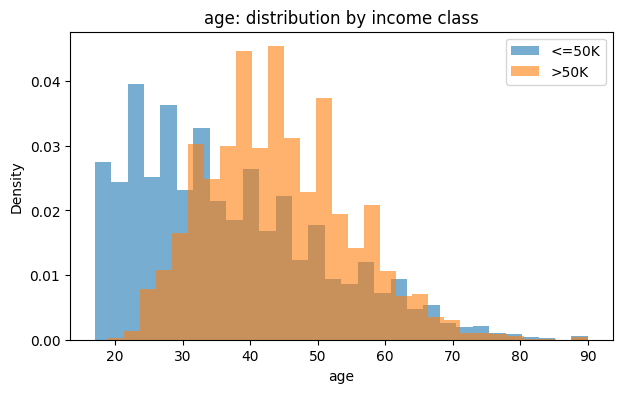

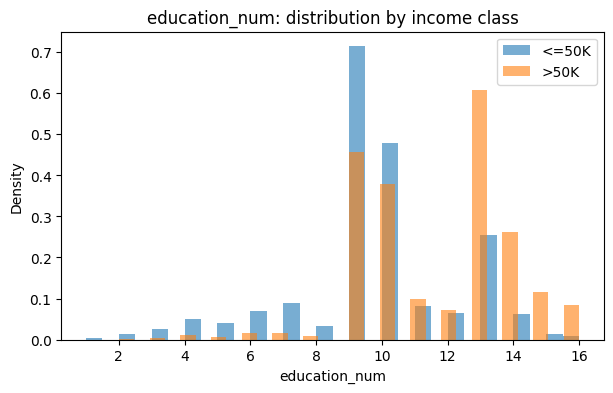

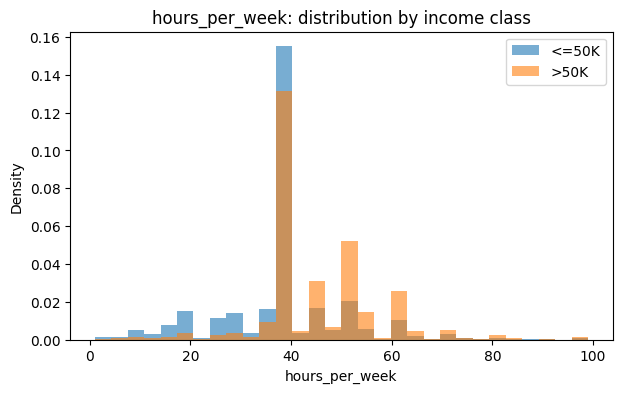

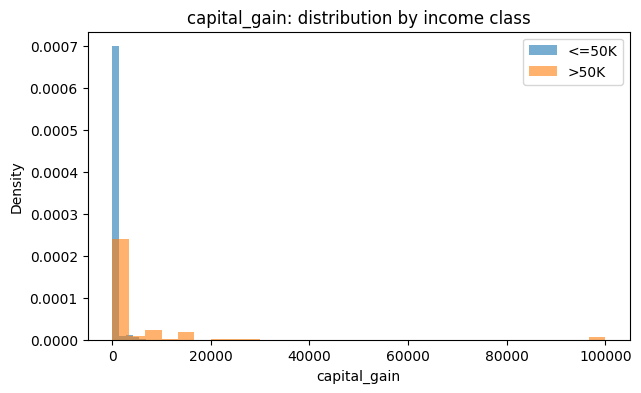

In [8]:
# Plot several representative numeric variables.
plot_features = ["age", "education_num", "hours_per_week", "capital_gain"]

for column in plot_features:
    plt.figure(figsize=(7, 4))
    plt.hist(
        train_raw.loc[y_dev_all == 0, column].dropna(),  # only take col match column and negtive
        bins=30,  #interval
        alpha=0.6,
        density=True,
        label="<=50K",
    )
    plt.hist(
        train_raw.loc[y_dev_all == 1, column].dropna(),
        bins=30,
        alpha=0.6,
        density=True,
        label=">50K",
    )
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.title(f"{column}: distribution by income class")
    plt.legend()
    plt.show()

In [9]:
# Example categorical EDA: income rate by occupation.
occupation_summary = (
    train_raw
    .assign(income_binary=y_dev_all)  # can calc prob ezily (e.g. 1+0+1+0+1/5 = 0.6 : 60% >50K)
    .groupby("occupation", dropna=False)
    .agg(
        count=("income_binary", "size"),
        positive_rate=("income_binary", "mean"),
    )
    # Avoid drawing conclusions from extremely tiny groups.
    .query("count >= 100")
    .sort_values("positive_rate", ascending=False)
)

display(occupation_summary)

,count,positive_rate
occupation,,
Exec-managerial,4066,0.484014
Prof-specialty,4140,0.449034
Protective-serv,649,0.325116
Tech-support,928,0.304957
Sales,3650,0.269315
Craft-repair,4099,0.226641
Transport-moving,1597,0.200376
Adm-clerical,3770,0.134483
Machine-op-inspct,2002,0.124875


From figure above you cant say Becoming an executive causes high income since it correlates education, age, experience, industry, hours...

## 5. Train / validation / official-test design

The official UCI test set remains untouched until final evaluation.

The original training file is split into:
- training: model fitting
- validation: model/threshold decisions

`stratify` preserves the positive-class proportion.

In [10]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev_all,
    y_dev_all,
    test_size=0.20,
    stratify=y_dev_all,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, "positive rate:", round(y_train.mean(), 4))
print("Valid:", X_valid.shape, "positive rate:", round(y_valid.mean(), 4))
print("Test :", X_test.shape, "positive rate:", round(y_test.mean(), 4))

Train: (26048, 14) positive rate: 0.2408
Valid: (6513, 14) positive rate: 0.2407
Test : (16281, 14) positive rate: 0.2362


## 6. Leakage-safe preprocessing

Converting categories to arbitrary integer IDs can can introduce fake ordering, e.g. one occupation may receive code 1 and another code 7 even though 7 is not "greater" than 1.

Modern preprocessing:
- numeric: median imputation + standardization
- categorical: most-frequent imputation + one-hot encoding
- everything is fitted inside a Pipeline so validation/test data never influence preprocessing statistics

In [11]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = [
    column for column in X_train.columns
    if column not in numeric_features
]

numeric_pipeline = Pipeline([
    # Learn the median from training data only.
    ("imputer", SimpleImputer(strategy="median")),   # nah -> median (not use mean cuz of extreme value)

    # Scaling is especially important for Logistic Regression and KNN. (age:17 ~ 90 capital_gain:0 ~ 99999)
    ("scaler", StandardScaler()),  #z=(x−μ)/σ:​ mean ≈ 0 std ≈ 1
])

categorical_pipeline = Pipeline([
    # Learn the most common category from training data only.
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # One-hot encoding avoids artificial numeric ordering.
    # Unknown categories at inference time are safely ignored.
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical features: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


## 7. Evaluation metrics

Because `>50K` is the minority class, accuracy alone can hide weak positive-class performance.

We use:
- ROC-AUC: probability-ranking quality
- PR-AUC / Average Precision: useful for imbalanced positive classes
- Precision
- Recall
- F1
- Accuracy for context

**ROC-AUC is computed from probabilities, not hard 0/1 predictions.**

In [12]:
def metric_dict(y_true, probabilities, threshold=0.50):
    # Convert probability estimates into hard predictions only for metrics
    # that require a class label.
    probabilities = np.asarray(probabilities)
    predictions = (probabilities >= threshold).astype(int)

    return {
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "accuracy": accuracy_score(y_true, predictions),
    }

def evaluate_model(name, fitted_model, X_eval, y_eval, threshold=0.50):
    # Every model in this notebook supports predict_proba().
    probabilities = fitted_model.predict_proba(X_eval)[:, 1] # [0.9, 0.1] get 2rd col which is 0.1: P(income > 50K)
    return {
        "model": name,
        **metric_dict(y_eval, probabilities, threshold),
    }

def show_confusion_and_report(y_true, probabilities, threshold=0.50):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    matrix = confusion_matrix(y_true, predictions)

    display(pd.DataFrame(
        matrix,
        index=["Actual <=50K", "Actual >50K"],
        columns=["Pred <=50K", "Pred >50K"],
    ))

    print(classification_report(
        y_true,
        predictions,
        target_names=["<=50K", ">50K"],
        digits=4,
    ))

## 8. Traditional ML baselines

We start with three complementary traditional model families:

1. **Logistic Regression** — interpretable linear baseline;
2. **Random Forest** — bagged tree ensemble for nonlinear interactions;
3. **XGBoost** — gradient-boosted trees, a particularly strong baseline for tabular data.

Starting with these models gives us a control group. A Transformer is only useful if its extra complexity produces a meaningful empirical improvement over these strong tabular baselines.

In [13]:
models = {
    "Logistic Regression": Pipeline([
        ("prep", clone(preprocessor)),
        ("model", LogisticRegression(
            max_iter=3000,
            # Give the minority class more weight.
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),

    "Random Forest": Pipeline([
        ("prep", clone(preprocessor)),
        ("model", RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),

    "XGBoost": Pipeline([
        ("prep", clone(preprocessor)),
        ("model", XGBClassifier(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}

validation_results = []
fitted_models = {}

for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train, y_train)
    fitted_models[name] = model
    validation_results.append(
        evaluate_model(name, model, X_valid, y_valid)
    )

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values("pr_auc", ascending=False)
)

display(validation_results_df)

Training Logistic Regression ...
Training Random Forest ...
Training XGBoost ...


,model,roc_auc,pr_auc,precision,recall,f1,accuracy
2,XGBoost,0.930470,0.835559,0.789234,0.663903,0.721164,0.876401
1,Random Forest,0.918969,0.798652,0.618234,0.830357,0.708764,0.835713
0,Logistic Regression,0.907578,0.770619,0.566525,0.852679,0.680754,0.807462


Result: We can see XGBoost gets highest pr_auc and accuracy since it can predict pos accurately, but it gets low recall, which means it is conservative and only predicts pos when prob >0.5, therefore missing some true pos values. However, LR and RF are doing the opposite(High Recall / Low Precision), meaning they are more active. 0.93 ROC_AUC means giving a true > 50k and a true < 50k case, XGBoost has 93% prob to give the true >50k a high predicted score (it does not care about threshold 0.5), so its reranking ability is good given low recall. Maybe XGBoost is not bad at finding pos, but threshold 0.5 is not good here.

Conclusion: XGBoost is currently the strongest model overall. It achieved the highest ROC-AUC and PR-AUC, indicating the best ranking performance, and also the highest F1 and accuracy at the default 0.5 threshold. Logistic Regression and Random Forest achieved substantially higher recall but lower precision, showing a more aggressive positive-class prediction behavior. The next step is therefore not to select a winner solely from this split, but to verify stability through cross-validation and later optimize the decision threshold.

## 9. Stratified 5-fold cross-validation

In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

cv_rows = []

for name, model in models.items():
    print(f"Cross-validating {name} ...")

    scores = cross_validate(
        model,
        X_dev_all,
        y_dev_all,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )

    row = {"model": name}

    # Mean = average performance.
    # Std = stability across folds.
    for metric_name in scoring:
        fold_scores = scores[f"test_{metric_name}"]
        row[f"{metric_name}_mean"] = fold_scores.mean()
        row[f"{metric_name}_std"] = fold_scores.std()

    cv_rows.append(row)

cv_results_df = (
    pd.DataFrame(cv_rows)
    .sort_values("pr_auc_mean", ascending=False)
)

display(cv_results_df)

Cross-validating Logistic Regression ...
Cross-validating Random Forest ...
Cross-validating XGBoost ...


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
2,XGBoost,0.928468,0.001453,0.829992,0.004081,0.784144,0.007555,0.651831,0.009336,0.711868,0.007818
1,Random Forest,0.916323,0.002107,0.792732,0.007077,0.626505,0.005940,0.810867,0.005914,0.706847,0.005096
0,Logistic Regression,0.905495,0.002467,0.762489,0.009912,0.568858,0.006669,0.848999,0.007989,0.681245,0.006981


## 11. Hyperparameter tuning

We tune XGBoost with `RandomizedSearchCV`.

The objective is **Average Precision / PR-AUC**, not accuracy, because positive-class performance matters and the classes are imbalanced.

In [15]:
xgb_search_pipeline = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

parameter_space = {
    "model__n_estimators": [250, 350, 500, 700], #boosting tree num
    "model__max_depth": [2, 3, 4, 5, 6],  # depth of tree
    "model__learning_rate": [0.02, 0.04, 0.06, 0.10],
    "model__subsample": [0.70, 0.85, 1.00],
    "model__colsample_bytree": [0.70, 0.85, 1.00],
    "model__min_child_weight": [1, 3, 5, 8],
    "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

search = RandomizedSearchCV(
    estimator=xgb_search_pipeline,
    param_distributions=parameter_space,
    n_iter=25,  # random pick 25 combination * 5 fold = 125 model fits
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

# Tune only on the training partition. Use training set only to do cv.
# Validation remains unseen for threshold selection and model comparison.
search.fit(X_train, y_train)

print("Best CV PR-AUC:", round(search.best_score_, 4))
print("Best parameters:")
print(json.dumps(search.best_params_, indent=2))

best_model = search.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV PR-AUC: 0.8286
Best parameters:
{
  "model__subsample": 0.85,
  "model__reg_lambda": 0.5,
  "model__n_estimators": 700,
  "model__min_child_weight": 1,
  "model__max_depth": 3,
  "model__learning_rate": 0.1,
  "model__colsample_bytree": 0.85
}


# Deep Learning Comparison

The next step is **not** to assume that deep learning must be better. We add two neural models as experimental groups:

- a standard **MLP** to test whether a generic feed-forward neural network already improves on boosted trees;
- an **FT-Transformer-style model** that tokenizes each tabular feature and applies self-attention across fields.

For deep models we use a fixed validation set and **early stopping** rather than expensive 5-fold cross-validation. This is a deliberate trade-off to keep the experiment practical in Colab.

## 12. PyTorch MLP baseline

In [16]:
# Reuse the traditional one-hot/scaled representation for the MLP.
# The preprocessor is fitted ONLY on X_train, then applied to validation/test.
mlp_preprocessor = clone(preprocessor)

X_train_mlp = mlp_preprocessor.fit_transform(X_train).astype(np.float32)
X_valid_mlp = mlp_preprocessor.transform(X_valid).astype(np.float32)
X_test_mlp = mlp_preprocessor.transform(X_test).astype(np.float32)

y_train_np = y_train.to_numpy(dtype=np.float32)
y_valid_np = y_valid.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)

print('MLP input shape:', X_train_mlp.shape)

MLP input shape: (26048, 105)


In [17]:
class MLPClassifierTorch(nn.Module):
    """Simple feed-forward neural-network baseline for tabular classification."""

    def __init__(self, input_dim, hidden_dims=(256, 128), dropout=0.25):
        super().__init__()

        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(previous_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout),
            ])
            previous_dim = hidden_dim

        # One output logit because this is binary classification.
        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(1)


def predict_mlp(model, X_array, batch_size=1024):
    """Return P(class=1) for a dense NumPy matrix."""
    model.eval()
    loader = DataLoader(
        torch.tensor(X_array, dtype=torch.float32),
        batch_size=batch_size,
        shuffle=False,
    )

    probabilities = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(DEVICE)
            logits = model(X_batch)
            probabilities.append(torch.sigmoid(logits).cpu().numpy())

    return np.concatenate(probabilities)


def train_mlp(
    model,
    X_train_array,
    y_train_array,
    X_valid_array,
    y_valid_array,
    epochs=40,
    learning_rate=1e-3,
    patience=6,
):
    """
    Train with class-weighted binary cross entropy and early stopping.

    Early stopping monitors validation PR-AUC. This prevents us from simply
    training for more epochs after generalization has stopped improving.
    """
    model = model.to(DEVICE)

    train_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_train_array, dtype=torch.float32),
            torch.tensor(y_train_array, dtype=torch.float32),
        ),
        batch_size=512,
        shuffle=True,
    )

    # Minority-class weighting is analogous in spirit to class_weight='balanced'.
    negatives = float((y_train_array == 0).sum())
    positives = float((y_train_array == 1).sum())
    pos_weight = torch.tensor([negatives / positives], dtype=torch.float32, device=DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) #L=−[ylog(p)+(1−y)log(1−p)]
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    best_state = None
    best_pr_auc = -np.inf
    no_improvement = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            losses.append(float(loss.item()))

        valid_probabilities = predict_mlp(model, X_valid_array)
        valid_pr_auc = average_precision_score(y_valid_array, valid_probabilities)

        history.append({
            'epoch': epoch,
            'train_loss': float(np.mean(losses)),
            'valid_pr_auc': float(valid_pr_auc),
        })

        if valid_pr_auc > best_pr_auc + 1e-4:
            best_pr_auc = valid_pr_auc
            best_state = deepcopy(model.state_dict())
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= patience:
            print(f'Early stopping at epoch {epoch}.')
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

Early stopping at epoch 10.
MLP training seconds: 11.22


,split,roc_auc,pr_auc,precision,recall,f1,accuracy
0,validation,0.916653,0.798063,0.578145,0.870536,0.694833,0.815907
1,official_test,0.910200,0.774872,0.568209,0.852314,0.681851,0.812112


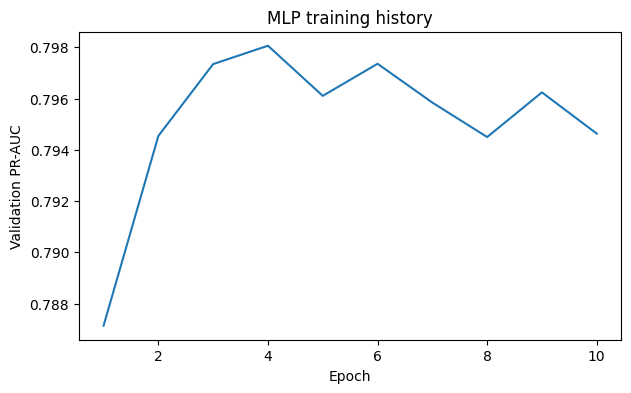

In [18]:
mlp_model = MLPClassifierTorch(input_dim=X_train_mlp.shape[1])

start_time = time.time()
mlp_model, mlp_history = train_mlp(
    mlp_model,
    X_train_mlp,
    y_train_np,
    X_valid_mlp,
    y_valid_np,
)
mlp_train_seconds = time.time() - start_time

mlp_valid_probabilities = predict_mlp(mlp_model, X_valid_mlp)
mlp_test_probabilities = predict_mlp(mlp_model, X_test_mlp)

mlp_validation_metrics = metric_dict(y_valid, mlp_valid_probabilities)
mlp_test_metrics = metric_dict(y_test, mlp_test_probabilities)

print('MLP training seconds:', round(mlp_train_seconds, 2))
display(pd.DataFrame([{'split': 'validation', **mlp_validation_metrics}, {'split': 'official_test', **mlp_test_metrics}]))

plt.figure(figsize=(7, 4))
plt.plot(mlp_history['epoch'], mlp_history['valid_pr_auc'])
plt.xlabel('Epoch')
plt.ylabel('Validation PR-AUC')
plt.title('MLP training history')
plt.show()

The MLP improved ranking performance over the linear baseline, particularly in PR-AUC, while maintaining similarly high recall.

## 13. FT-Transformer-style tabular model

In [19]:
# Transformer preprocessing is different from MLP preprocessing.
#
# Categorical fields are integer IDs used ONLY to look up trainable embeddings.
# They are not treated as ordered numerical measurements.
#
# Numerical fields are median-imputed and standardized.
transformer_num_imputer = SimpleImputer(strategy='median')
transformer_num_scaler = StandardScaler()

X_train_num = transformer_num_scaler.fit_transform(
    transformer_num_imputer.fit_transform(X_train[numeric_features])
).astype(np.float32)

X_valid_num = transformer_num_scaler.transform(
    transformer_num_imputer.transform(X_valid[numeric_features])
).astype(np.float32)

X_test_num = transformer_num_scaler.transform(
    transformer_num_imputer.transform(X_test[numeric_features])
).astype(np.float32)

transformer_cat_imputer = SimpleImputer(strategy='most_frequent')

train_cat_text = transformer_cat_imputer.fit_transform(X_train[categorical_features])
valid_cat_text = transformer_cat_imputer.transform(X_valid[categorical_features])
test_cat_text = transformer_cat_imputer.transform(X_test[categorical_features])

transformer_cat_encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1,
)

X_train_cat = transformer_cat_encoder.fit_transform(train_cat_text)
X_valid_cat = transformer_cat_encoder.transform(valid_cat_text)
X_test_cat = transformer_cat_encoder.transform(test_cat_text)

# Shift IDs by +1 so zero is reserved for unseen categories.
X_train_cat = (X_train_cat + 1).astype(np.int64)
X_valid_cat = (X_valid_cat + 1).astype(np.int64)
X_test_cat = (X_test_cat + 1).astype(np.int64)

categorical_cardinalities = [
    len(categories) + 1
    for categories in transformer_cat_encoder.categories_
]

print('Numeric feature tokens:', len(numeric_features))
print('Categorical feature tokens:', len(categorical_features))
print('Categorical cardinalities:', categorical_cardinalities)

Numeric feature tokens: 6
Categorical feature tokens: 8
Categorical cardinalities: [9, 17, 8, 15, 7, 6, 3, 42]


In [20]:
class TabularTransformer(nn.Module):
    """
    Compact FT-Transformer-style classifier.

    Core idea:
    1. each categorical field gets its own embedding table;
    2. each numerical scalar is projected into the same token dimension;
    3. a learnable [CLS] token is prepended;
    4. self-attention learns interactions between feature tokens;
    5. the [CLS] representation is used for binary classification.
    """

    def __init__(
        self,
        num_numeric,
        categorical_cardinalities,
        token_dim=32,
        num_heads=4,
        num_layers=2,
        ff_dim=128,
        dropout=0.15,
    ):
        super().__init__()

        self.category_embeddings = nn.ModuleList([
            nn.Embedding(cardinality, token_dim)
            for cardinality in categorical_cardinalities
        ])

        # Numerical tokenizer: value_j * weight_j + bias_j
        # Every scalar feature becomes a token vector.
        self.numeric_weight = nn.Parameter(torch.randn(num_numeric, token_dim) * 0.02)
        self.numeric_bias = nn.Parameter(torch.zeros(num_numeric, token_dim))

        self.cls_token = nn.Parameter(torch.zeros(1, 1, token_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=token_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.final_norm = nn.LayerNorm(token_dim)

        self.head = nn.Sequential(
            nn.Linear(token_dim, token_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(token_dim, 1),
        )

    def forward(self, numeric_x, categorical_x):
        batch_size = numeric_x.size(0)

        numeric_tokens = (
            numeric_x.unsqueeze(-1) * self.numeric_weight.unsqueeze(0)
            + self.numeric_bias.unsqueeze(0)
        )

        categorical_tokens = torch.stack([
            embedding(categorical_x[:, feature_index])
            for feature_index, embedding in enumerate(self.category_embeddings)
        ], dim=1)

        cls = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls, numeric_tokens, categorical_tokens], dim=1)

        encoded = self.transformer(tokens)
        cls_output = self.final_norm(encoded[:, 0])
        return self.head(cls_output).squeeze(1)

In [21]:
def predict_transformer(model, numeric_array, categorical_array, batch_size=1024):
    model.eval()

    loader = DataLoader(
        TensorDataset(
            torch.tensor(numeric_array, dtype=torch.float32),
            torch.tensor(categorical_array, dtype=torch.long),
        ),
        batch_size=batch_size,
        shuffle=False,
    )

    probabilities = []

    with torch.no_grad():
        for numeric_batch, categorical_batch in loader:
            numeric_batch = numeric_batch.to(DEVICE)
            categorical_batch = categorical_batch.to(DEVICE)
            logits = model(numeric_batch, categorical_batch)
            probabilities.append(torch.sigmoid(logits).cpu().numpy())

    return np.concatenate(probabilities)


def train_transformer(
    model,
    train_numeric,
    train_categorical,
    train_labels,
    valid_numeric,
    valid_categorical,
    valid_labels,
    epochs=35,
    learning_rate=2e-4,
    patience=6,
):
    """Train with weighted BCE, AdamW, gradient clipping, and early stopping."""
    model = model.to(DEVICE)

    train_loader = DataLoader(
        TensorDataset(
            torch.tensor(train_numeric, dtype=torch.float32),
            torch.tensor(train_categorical, dtype=torch.long),
            torch.tensor(train_labels, dtype=torch.float32),
        ),
        batch_size=512,
        shuffle=True,
    )

    negatives = float((train_labels == 0).sum())
    positives = float((train_labels == 1).sum())
    pos_weight = torch.tensor([negatives / positives], dtype=torch.float32, device=DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    best_state = None
    best_pr_auc = -np.inf
    no_improvement = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []

        for numeric_batch, categorical_batch, y_batch in train_loader:
            numeric_batch = numeric_batch.to(DEVICE)
            categorical_batch = categorical_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            logits = model(numeric_batch, categorical_batch)
            loss = criterion(logits, y_batch)
            loss.backward()

            # Transformers can occasionally produce unstable gradients.
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            losses.append(float(loss.item()))

        valid_probabilities = predict_transformer(model, valid_numeric, valid_categorical)
        valid_pr_auc = average_precision_score(valid_labels, valid_probabilities)

        history.append({
            'epoch': epoch,
            'train_loss': float(np.mean(losses)),
            'valid_pr_auc': float(valid_pr_auc),
        })

        if valid_pr_auc > best_pr_auc + 1e-4:
            best_pr_auc = valid_pr_auc
            best_state = deepcopy(model.state_dict())
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= patience:
            print(f'Early stopping at epoch {epoch}.')
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

Transformer training seconds: 232.25


,split,roc_auc,pr_auc,precision,recall,f1,accuracy
0,validation,0.917964,0.800445,0.594690,0.857143,0.702194,0.824965
1,official_test,0.910960,0.779770,0.580628,0.827613,0.682461,0.818070


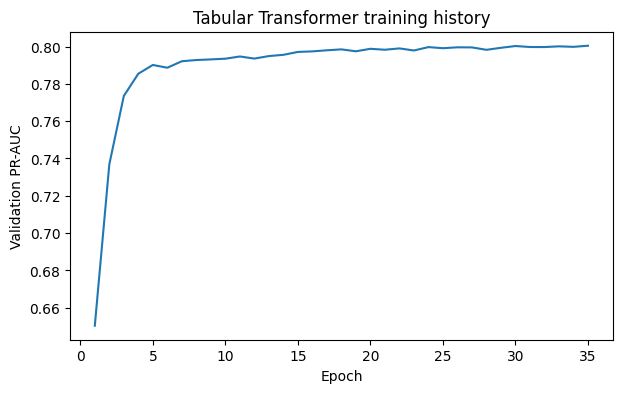

In [22]:
transformer_model = TabularTransformer(
    num_numeric=len(numeric_features),
    categorical_cardinalities=categorical_cardinalities,
    token_dim=32,
    num_heads=4,
    num_layers=2,
    ff_dim=128,
    dropout=0.15,
)

start_time = time.time()
transformer_model, transformer_history = train_transformer(
    transformer_model,
    X_train_num,
    X_train_cat,
    y_train_np,
    X_valid_num,
    X_valid_cat,
    y_valid_np,
)
transformer_train_seconds = time.time() - start_time

transformer_valid_probabilities = predict_transformer(
    transformer_model,
    X_valid_num,
    X_valid_cat,
)
transformer_test_probabilities = predict_transformer(
    transformer_model,
    X_test_num,
    X_test_cat,
)

transformer_validation_metrics = metric_dict(y_valid, transformer_valid_probabilities)
transformer_test_metrics = metric_dict(y_test, transformer_test_probabilities)

print('Transformer training seconds:', round(transformer_train_seconds, 2))
display(pd.DataFrame([
    {'split': 'validation', **transformer_validation_metrics},
    {'split': 'official_test', **transformer_test_metrics},
]))

plt.figure(figsize=(7, 4))
plt.plot(transformer_history['epoch'], transformer_history['valid_pr_auc'])
plt.xlabel('Epoch')
plt.ylabel('Validation PR-AUC')
plt.title('Tabular Transformer training history')
plt.show()

On the Adult Income dataset, the Tabular Transformer provided only a marginal improvement over the MLP and performed similarly to Random Forest, while XGBoost remained clearly stronger in PR-AUC and ROC-AUC. The additional architectural complexity of the Transformer therefore did not translate into a meaningful predictive advantage.

## 14. Traditional ML vs deep learning comparison

In [23]:
# Compare ranking metrics on the same validation and official test partitions.
# PR-AUC and ROC-AUC do not depend on choosing a single probability threshold,
# making them particularly useful for cross-model comparison.

tuned_xgb_valid_probabilities = best_model.predict_proba(X_valid)[:, 1]
tuned_xgb_test_probabilities = best_model.predict_proba(X_test)[:, 1]

comparison_rows = [
    {
        'model': 'Tuned XGBoost',
        'family': 'Traditional ML',
        'validation_pr_auc': average_precision_score(y_valid, tuned_xgb_valid_probabilities),
        'validation_roc_auc': roc_auc_score(y_valid, tuned_xgb_valid_probabilities),
        'test_pr_auc': average_precision_score(y_test, tuned_xgb_test_probabilities),
        'test_roc_auc': roc_auc_score(y_test, tuned_xgb_test_probabilities),
    },
    {
        'model': 'PyTorch MLP',
        'family': 'Deep Learning',
        'validation_pr_auc': average_precision_score(y_valid, mlp_valid_probabilities),
        'validation_roc_auc': roc_auc_score(y_valid, mlp_valid_probabilities),
        'test_pr_auc': average_precision_score(y_test, mlp_test_probabilities),
        'test_roc_auc': roc_auc_score(y_test, mlp_test_probabilities),
        'train_seconds': mlp_train_seconds,
    },
    {
        'model': 'Tabular Transformer',
        'family': 'Deep Learning',
        'validation_pr_auc': average_precision_score(y_valid, transformer_valid_probabilities),
        'validation_roc_auc': roc_auc_score(y_valid, transformer_valid_probabilities),
        'test_pr_auc': average_precision_score(y_test, transformer_test_probabilities),
        'test_roc_auc': roc_auc_score(y_test, transformer_test_probabilities),
        'train_seconds': transformer_train_seconds,
    },
]

model_family_comparison = pd.DataFrame(comparison_rows).sort_values(
    'validation_pr_auc',
    ascending=False,
)

display(model_family_comparison)

print('\nResearch interpretation:')
print('- Do not assume the highest number automatically wins in practice.')
print('- Compare the gain against extra training cost, complexity, and explainability.')
print('- A very small PR-AUC improvement may not justify a Transformer.')

,model,family,validation_pr_auc,validation_roc_auc,test_pr_auc,test_roc_auc,train_seconds
0,Tuned XGBoost,Traditional ML,0.836900,0.931307,0.822621,0.925973,NaN
2,Tabular Transformer,Deep Learning,0.800445,0.917964,0.779770,0.910960,232.252604
1,PyTorch MLP,Deep Learning,0.798063,0.916653,0.774872,0.910200,11.217311



Research interpretation:
- Do not assume the highest number automatically wins in practice.
- Compare the gain against extra training cost, complexity, and explainability.
- A very small PR-AUC improvement may not justify a Transformer.


Tuned XGBoost materially outperformed both neural approaches on the Adult Income dataset.
I found that model complexity did not translate directly into better performance. The tabular Transformer slightly improved over the MLP, but the gain was less than 0.005 PR-AUC while requiring roughly 19 times more training time. Tuned XGBoost achieved a substantially higher PR-AUC on both validation and the untouched official test set, so it was the better practical model for this dataset.

## 15. MLflow experiment tracking

MLflow records:
- tuned hyperparameters
- validation metrics
- the full fitted Pipeline

In Colab, this uses a local experiment store. No separate server is required for this research project.

In [24]:
# Refit/evaluate the tuned model on validation data.
valid_probabilities = best_model.predict_proba(X_valid)[:, 1]
valid_metrics = metric_dict(y_valid, valid_probabilities)

mlflow.set_experiment("adult-income-applied-ml-research")   # set log for exp

with mlflow.start_run(run_name="tuned_xgboost"):
    mlflow.log_params(search.best_params_)

    for metric_name, value in valid_metrics.items():
        mlflow.log_metric(
            f"validation_{metric_name}",
            float(value),
        )

    mlflow.sklearn.log_model(
        best_model,
        name="model",
        serialization_format="cloudpickle",
    )

print("MLflow run logged.")
print(valid_metrics)

2026/08/28 21:26:06 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/28 21:26:06 INFO mlflow.store.db.utils: Updating database tables
2026/08/28 21:26:10 INFO mlflow.tracking.fluent: Experiment with name 'adult-income-applied-ml-research' does not exist. Creating a new experiment.
2026/08/28 21:26:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged.
{'roc_auc': np.float64(0.931306553207734), 'pr_auc': np.float64(0.836900250620775), 'precision': 0.7850746268656716, 'recall': 0.6709183673469388, 'f1': 0.7235213204951857, 'accuracy': 0.8765545831414094}


In [25]:
!pkill -f "mlflow"

!mlflow server \
    --host 0.0.0.0 \
    --port 5000 \
    --allowed-hosts "*" \
    --cors-allowed-origins "*" \
    --x-frame-options NONE \
    > /tmp/mlflow.log 2>&1 &

In [26]:
import time
time.sleep(3)

!cat /tmp/mlflow.log

In [27]:
from google.colab import output
from IPython.display import display, HTML

mlflow_url = output.eval_js(
    "google.colab.kernel.proxyPort(5000)"
)

print(mlflow_url)

display(
    HTML(
        f'<a href="{mlflow_url}" target="_blank">'
        'Open MLflow UI'
        '</a>'
    )
)

https://5000-m-s-kkb-usw4b2-1sze7thwfkbuy-b.us-west4-2.prod.colab.dev


In [28]:
experiment = mlflow.get_experiment_by_name(
    "adult-income-applied-ml-research"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

display(runs)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.validation_roc_auc,metrics.validation_accuracy,metrics.validation_recall,metrics.validation_pr_auc,...,params.model__reg_lambda,params.model__n_estimators,params.model__min_child_weight,params.model__max_depth,params.model__colsample_bytree,params.model__learning_rate,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.source.type
0,010bf16461104eb08cd6984b99dec065,1,FINISHED,/content/mlruns/1/010bf16461104eb08cd6984b99de...,2026-08-28 21:26:10.339000+00:00,2026-08-28 21:26:17.590000+00:00,0.931307,0.876555,0.670918,0.8369,...,0.5,700,1,3,0.85,0.1,root,fileId=1msWfQyz7YdoMYqnScOpctJ_-vs-SCnzz,tuned_xgboost,NOTEBOOK


## 16. Threshold optimization

The default 0.50 classification threshold is arbitrary.

We select a threshold using the **validation set only**. This example maximizes F1, but a real use case could instead require a minimum recall or precision.

Selected threshold: 0.4


,threshold,roc_auc,pr_auc,precision,recall,f1,accuracy
15,0.40,0.931307,0.8369,0.718259,0.757653,0.737430,0.870106
14,0.38,0.931307,0.8369,0.703553,0.770408,0.735464,0.866575
12,0.34,0.931307,0.8369,0.677419,0.803571,0.735123,0.860587
13,0.36,0.931307,0.8369,0.689174,0.787628,0.735119,0.863350
16,0.42,0.931307,0.8369,0.729560,0.739796,0.734642,0.871334
11,0.32,0.931307,0.8369,0.663909,0.818878,0.733295,0.856595
10,0.30,0.931307,0.8369,0.651070,0.834184,0.731339,0.852449
17,0.44,0.931307,0.8369,0.738903,0.721939,0.730323,0.871641
18,0.46,0.931307,0.8369,0.755997,0.703444,0.728774,0.873944
9,0.28,0.931307,0.8369,0.637584,0.848214,0.727969,0.847382


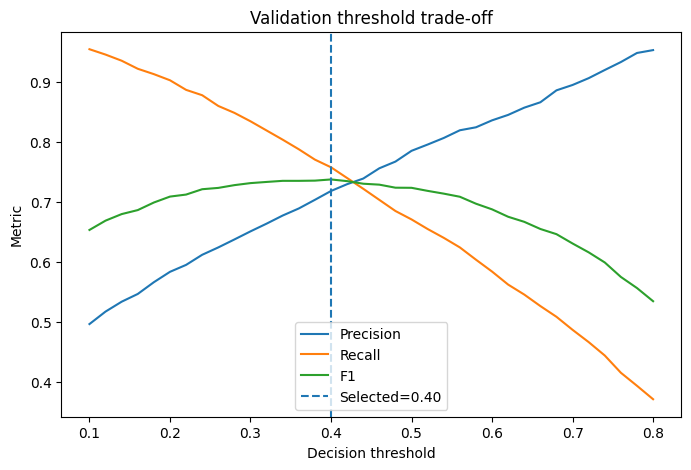

In [29]:
threshold_rows = []

for threshold in np.arange(0.10, 0.81, 0.02):
    metrics = metric_dict(
        y_valid,
        valid_probabilities,
        threshold=threshold,
    )
    threshold_rows.append({
        "threshold": float(threshold),
        **metrics,
    })

threshold_df = pd.DataFrame(threshold_rows)
# dep on the real case, not always f1
# fraud: prec, disease: recall, bank: FP/FN
best_index = threshold_df["f1"].idxmax()
selected_threshold = float(
    threshold_df.loc[best_index, "threshold"]  #loc[row, col]
)

print("Selected threshold:", round(selected_threshold, 3))
display(threshold_df.sort_values("f1", ascending=False).head(12))

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected={selected_threshold:.2f}",
)
plt.xlabel("Decision threshold")
plt.ylabel("Metric")
plt.title("Validation threshold trade-off")
plt.legend()
plt.show()

## 17. Final evaluation on the official UCI test set

Only now do we use `adult.test`.

The official test set has not participated in:
- preprocessing fit
- model selection
- hyperparameter tuning
- threshold selection

,model,threshold,roc_auc,pr_auc,precision,recall,f1,accuracy
0,Tuned XGBoost,0.4,0.925973,0.822621,0.701215,0.735309,0.717858,0.86346


,Pred <=50K,Pred >50K
Actual <=50K,11230,1205
Actual >50K,1018,2828


              precision    recall  f1-score   support

       <=50K     0.9169    0.9031    0.9099     12435
        >50K     0.7012    0.7353    0.7179      3846

    accuracy                         0.8635     16281
   macro avg     0.8090    0.8192    0.8139     16281
weighted avg     0.8659    0.8635    0.8646     16281



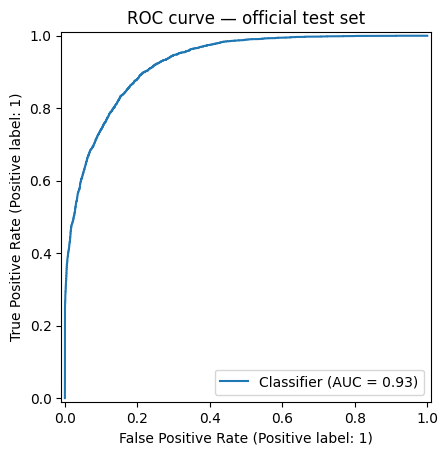

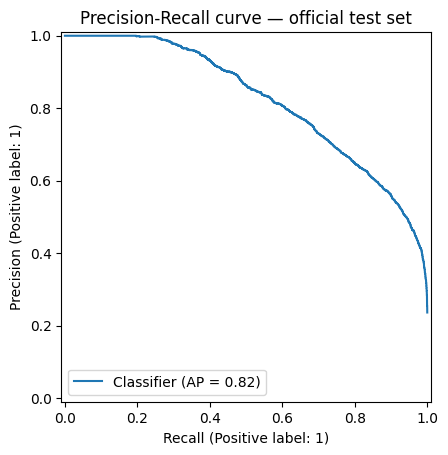

In [30]:
test_probabilities = best_model.predict_proba(X_test)[:, 1]

test_metrics = metric_dict(
    y_test,
    test_probabilities,
    threshold=selected_threshold,
)

display(pd.DataFrame([{
    "model": "Tuned XGBoost",
    "threshold": selected_threshold,
    **test_metrics,
}]))

show_confusion_and_report(
    y_test,
    test_probabilities,
    threshold=selected_threshold,
)

RocCurveDisplay.from_predictions(y_test, test_probabilities)
plt.title("ROC curve — official test set")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_probabilities)
plt.title("Precision-Recall curve — official test set")
plt.show()

## 18. Probability calibration

Ranking metrics such as ROC-AUC do not guarantee that a score of 0.80 behaves like an 80% probability.

Calibration is useful when the probability itself matters. Calibrate so that it is more towards to the real ones according to prediction vs actual.

Validation ROC-AUC before calibration: 0.9313
Validation ROC-AUC after calibration: 0.9312


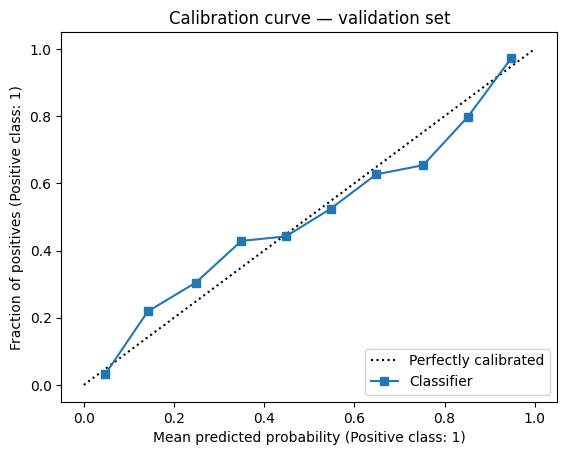

In [31]:
calibrated_model = CalibratedClassifierCV(
    estimator=clone(best_model),
    method="sigmoid",
    cv=5,
)

# Calibration is fitted only on training data.
calibrated_model.fit(X_train, y_train)

calibrated_valid_probabilities = (
    calibrated_model.predict_proba(X_valid)[:, 1]
)

print(
    "Validation ROC-AUC before calibration:",
    round(roc_auc_score(y_valid, valid_probabilities), 4),
)
print(
    "Validation ROC-AUC after calibration:",
    round(roc_auc_score(y_valid, calibrated_valid_probabilities), 4),
)

CalibrationDisplay.from_predictions(
    y_valid,
    calibrated_valid_probabilities,
    n_bins=10,
)
plt.title("Calibration curve — validation set")
plt.show()

The calibrated XGBoost probabilities broadly track the observed positive rates, with some moderate deviations in individual probability bins.

## 19. Statistical Logistic Regression: coefficients, confidence intervals, odds ratios

statistical-modeling: which var related to income? how? certain?

For a small set of numeric predictors:
- coefficient > 0 means higher log-odds of `>50K`
- `exp(coefficient)` is an odds ratio
- confidence intervals quantify uncertainty

These are **associations**, not causal effects.

In [32]:
# pick num attributes, ez to do analysis
stats_features = [
    "age",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
]

stats_X = X_dev_all[stats_features].copy()

# Defensive fill; Adult's numeric fields are usually complete.
stats_X = stats_X.fillna(stats_X.median())

# Add intercept.
stats_X = sm.add_constant(stats_X)

# log(p/1-p)
logit_model = sm.Logit(
    y_dev_all,
    stats_X,
).fit(disp=False)

print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                 income   No. Observations:                32561
Model:                          Logit   Df Residuals:                    32555
Method:                           MLE   Df Model:                            5
Date:                Fri, 28 Aug 2026   Pseudo R-squ.:                  0.2632
Time:                        21:27:14   Log-Likelihood:                -13243.
converged:                       True   LL-Null:                       -17974.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -8.3157      0.115    -72.240      0.000      -8.541      -8.090
age                0.0430      0.001     35.211      0.000       0.041       0.045
education_num      0.3228      0.007

In [33]:
confidence = logit_model.conf_int()

odds_ratio_table = pd.DataFrame({
    "coefficient": logit_model.params,
    "odds_ratio": np.exp(logit_model.params), # odds = p/1-p, OR = OR after/ OR before, OR=1: no relationship
    "ci_lower_odds_ratio": np.exp(confidence[0]),
    "ci_upper_odds_ratio": np.exp(confidence[1]),
    "p_value": logit_model.pvalues,
})

display(odds_ratio_table)

,coefficient,odds_ratio,ci_lower_odds_ratio,ci_upper_odds_ratio,p_value
const,-8.315656,0.000245,0.000195,0.000307,0.000000e+00
age,0.043019,1.043958,1.041461,1.046461,1.338591e-271
education_num,0.322750,1.380920,1.362599,1.399488,0.000000e+00
capital_gain,0.000319,1.000319,1.000300,1.000338,1.284252e-237
capital_loss,0.000699,1.000699,1.000635,1.000763,2.406791e-102
hours_per_week,0.040724,1.041565,1.038867,1.044270,5.567183e-208


CI: if OR = 1.10 and 95% CI = [0.91, 1.31], it contains 1, meaning uncertain about pos or neg correlation.
P = P(observed result this extreme or more∣H0​): p=0 not ez to see this to happen, therefore H0 (attribute has no relation with income) might be false, reject it. if p is small (<0.05), meaning H0 can be false ().

check 3 values for correlation:
p-value
→ evidence

effect size / OR
→ how influence

confidence interval
→ effect how precise

After adjusting for the other variables included in this logistic regression, hours worked per week was positively associated with the odds of earning >50K (OR = 1.042, 95% CI [1.039, 1.044], p < .001).

## 20. SHAP explainability

SHAP is used at two levels:
- **global**: which transformed features matter across many rows?
- **local**: why did the model assign this score to one row?

Because XGBoost is inside a preprocessing Pipeline, SHAP receives the transformed matrix that the tree model actually uses.

In [34]:
fitted_preprocessor = best_model.named_steps["prep"]
fitted_xgb = best_model.named_steps["model"]

# Limit the explanation sample so Colab remains responsive.
SHAP_SAMPLE_SIZE = min(2000, len(X_test))

X_shap_raw = X_test.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

X_shap_transformed = fitted_preprocessor.transform(X_shap_raw)
transformed_feature_names = fitted_preprocessor.get_feature_names_out()

X_shap_df = pd.DataFrame(
    X_shap_transformed,
    columns=transformed_feature_names,
    index=X_shap_raw.index,
)

explainer = shap.TreeExplainer(fitted_xgb)
shap_values = explainer(X_shap_df)

print("SHAP matrix:", X_shap_df.shape)

SHAP matrix: (2000, 105)


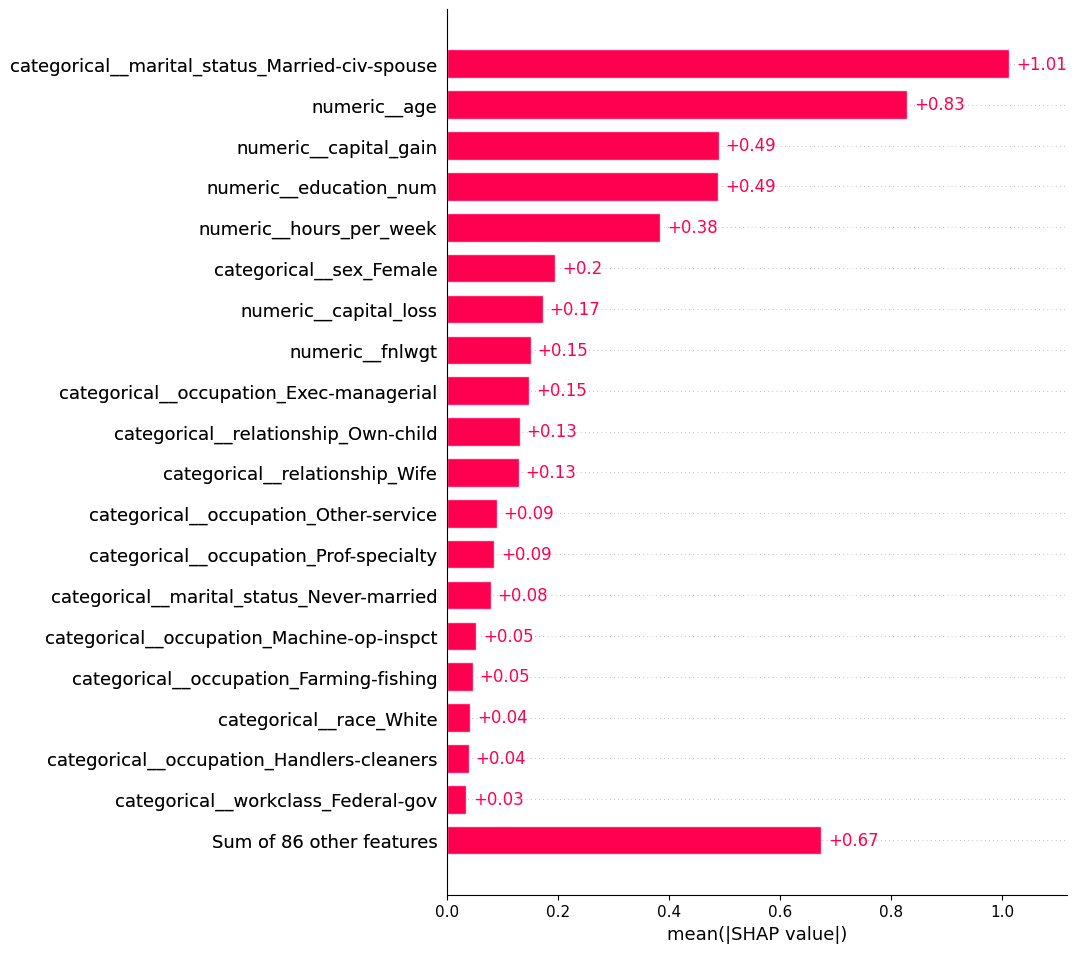

In [35]:
# Global mean absolute contribution.
shap.plots.bar(shap_values, max_display=20)

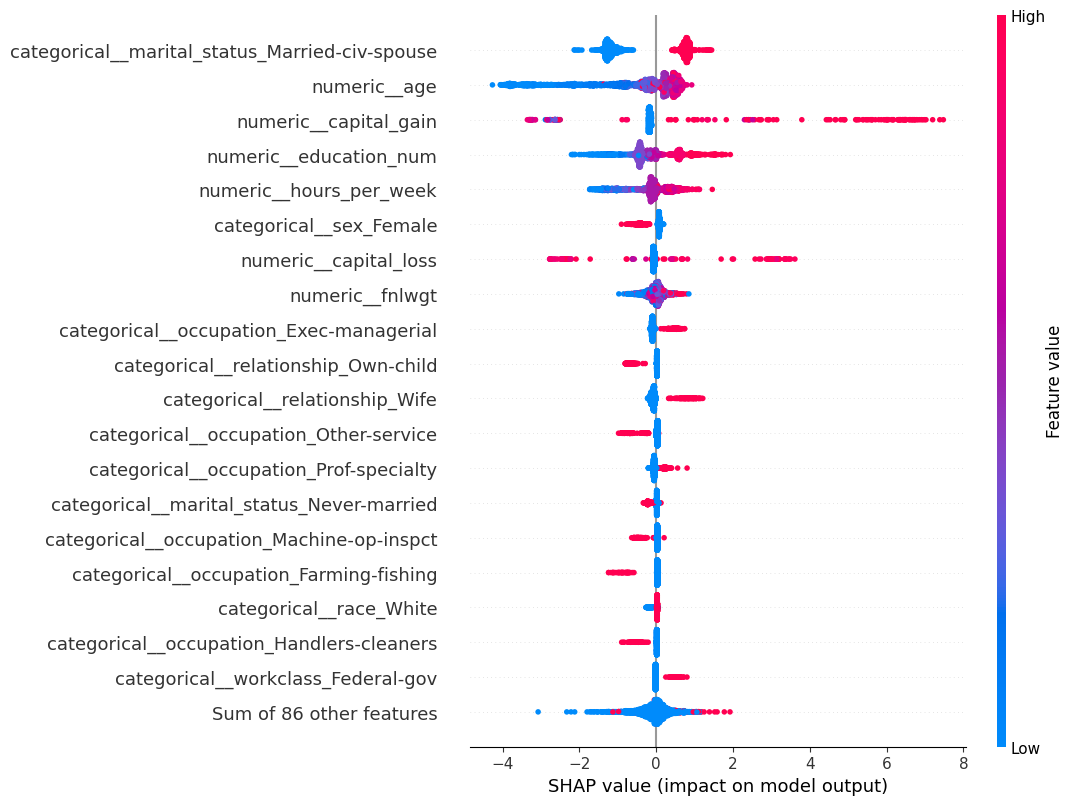

In [36]:
# Beeswarm shows both importance and direction of feature effects.
shap.plots.beeswarm(shap_values, max_display=20)

Test index: 13633
Predicted P(>50K): 0.0104
Actual class: 0


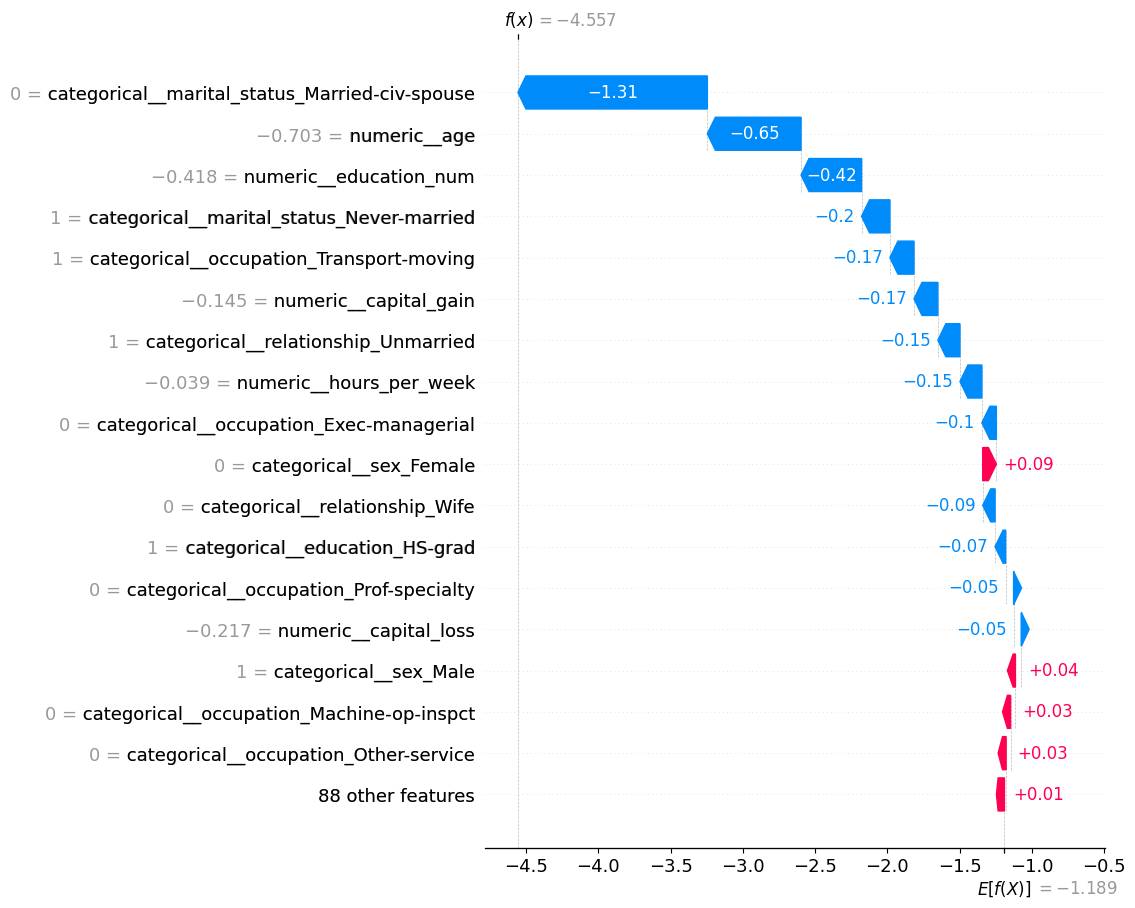

In [37]:
# Local explanation for one sampled test row.
local_position = 0
original_index = X_shap_df.index[local_position]

local_row = X_test.loc[[original_index]]
local_probability = float(
    best_model.predict_proba(local_row)[:, 1][0]
)

print("Test index:", original_index)
print("Predicted P(>50K):", round(local_probability, 4))
print("Actual class:", int(y_test.loc[original_index]))

shap.plots.waterfall(
    shap_values[local_position],
    max_display=18,
)

predict income < 50k using large negative contributions: not Married-civ-spouse”、 young、low education_num

## 21. Error analysis

We inspect both error directions:
- False Negative: actual `>50K`, predicted `<=50K`
- False Positive: actual `<=50K`, predicted `>50K`

This helps answer *where* the model fails rather than stopping at one global score.

In [38]:
test_predictions = (
    test_probabilities >= selected_threshold
).astype(int)

error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["prediction"] = test_predictions
error_df["probability_gt_50k"] = test_probabilities

false_negatives = error_df[
    (error_df["actual"] == 1)
    & (error_df["prediction"] == 0)
].copy()

false_positives = error_df[
    (error_df["actual"] == 0)
    & (error_df["prediction"] == 1)
].copy()

print("False negatives:", len(false_negatives))
print("False positives:", len(false_positives))

print("\nHighest-probability false positives:")
display(
    false_positives
    .sort_values("probability_gt_50k", ascending=False)
    .head(10)
)

print("\nLowest-probability false negatives:")
display(
    false_negatives
    .sort_values("probability_gt_50k", ascending=True)
    .head(10)
)

False negatives: 1018
False positives: 1205

Highest-probability false positives:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,actual,prediction,probability_gt_50k
13783,51,Private,183200,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1902,40,United-States,0,1,0.981876
3605,36,Self-emp-not-inc,240191,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male,41310,0,90,South,0,1,0.978083
2926,65,Self-emp-not-inc,176835,Masters,14,Married-spouse-absent,Prof-specialty,Not-in-family,White,Female,7978,0,40,United-States,0,1,0.944966
11265,38,Private,99783,Assoc-voc,11,Married-civ-spouse,Other-service,Wife,White,Female,0,1902,40,United-States,0,1,0.935807
4143,64,Private,159715,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,10566,0,40,United-States,0,1,0.931684
11879,50,Private,392668,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,4386,0,40,United-States,0,1,0.929014
10208,44,Private,146659,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,0,1,0.926414
5838,44,NaN,118484,Prof-school,15,Married-civ-spouse,NaN,Husband,White,Male,0,0,80,United-States,0,1,0.915875
10138,54,Private,548361,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,98,United-States,0,1,0.909510
3048,43,Federal-gov,190020,Prof-school,15,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,0,1,0.908269



Lowest-probability false negatives:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,actual,prediction,probability_gt_50k
10408,22,NaN,52596,Some-college,10,Never-married,NaN,Own-child,White,Male,0,0,15,NaN,1,0,0.000294
5953,20,Private,325033,12th,8,Never-married,Other-service,Own-child,Black,Male,0,0,35,United-States,1,0,0.000366
3059,22,Private,185582,Some-college,10,Never-married,Sales,Not-in-family,White,Male,0,0,25,United-States,1,0,0.002051
7720,23,Private,239539,Some-college,10,Never-married,Craft-repair,Own-child,Asian-Pac-Islander,Male,0,0,40,NaN,1,0,0.002529
2004,65,Local-gov,200764,HS-grad,9,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,16,United-States,1,0,0.003024
6035,30,Local-gov,38268,HS-grad,9,Separated,Other-service,Unmarried,White,Male,0,0,40,United-States,1,0,0.004177
15088,90,Private,197613,HS-grad,9,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,1,0,0.004792
10535,21,Private,186087,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,40,United-States,1,0,0.005526
12808,67,Private,126361,11th,7,Married-civ-spouse,Other-service,Husband,Black,Male,0,0,9,United-States,1,0,0.005625
11821,24,Private,360077,11th,7,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,1,0,0.006687


In [39]:
# Compare numeric averages for correct vs incorrect predictions.
error_df["correct"] = (
    error_df["actual"] == error_df["prediction"]
)

comparison_rows = []

for column in numeric_features:
    correct_mean = pd.to_numeric(
        error_df.loc[error_df["correct"], column],
        errors="coerce",
    ).mean()

    incorrect_mean = pd.to_numeric(
        error_df.loc[~error_df["correct"], column],
        errors="coerce",
    ).mean()

    comparison_rows.append({
        "feature": column,
        "correct_mean": correct_mean,
        "error_mean": incorrect_mean,
        "absolute_difference": abs(incorrect_mean - correct_mean),
    })

display(
    pd.DataFrame(comparison_rows)
    .sort_values("absolute_difference", ascending=False)
)

,feature,correct_mean,error_mean,absolute_difference
1,fnlwgt,190151.484706,184908.995951,5242.488755
3,capital_gain,1239.134514,87.604139,1151.530376
4,capital_loss,95.933703,37.090418,58.843285
0,age,37.930147,44.062528,6.132382
5,hours_per_week,39.701949,44.757535,5.055586
2,education_num,9.960876,10.781377,0.820500


## 22. Subgroup performance diagnostics

The dataset contains sensitive and demographic attributes.

Here they are used for **diagnostic evaluation**, not to justify individual decisions.

For each sufficiently large subgroup we compute:
- sample size
- positive prevalence
- ROC-AUC
- precision
- recall
- F1

Differences are signals for investigation, not proof of fairness or unfairness.

Consider this:
Group A:
Recall = 0.85

Group B:
Recall = 0.42

overall recall can still be 0.74

In [40]:
def subgroup_report(
    X_part,
    y_true,
    probabilities,
    group_column,
    threshold,
    min_group_size=100,
):
    temp = X_part[[group_column]].copy()
    temp["actual"] = y_true.values
    temp["probability"] = probabilities
    temp["prediction"] = (
        probabilities >= threshold
    ).astype(int)

    rows = []

    for group_value, part in temp.groupby(group_column, dropna=False):
        # Skip small groups and groups with only one target class because
        # metrics such as ROC-AUC would be unstable/undefined.
        if len(part) < min_group_size:
            continue
        if part["actual"].nunique() < 2:
            continue

        rows.append({
            "group": group_value,
            "n": len(part),
            "positive_rate": part["actual"].mean(),
            "roc_auc": roc_auc_score(  # ability to distinguish neg from pos (pos higher than neg)
                part["actual"],
                part["probability"],
            ),
            "precision": precision_score(
                part["actual"],
                part["prediction"],
                zero_division=0,
            ),
            "recall": recall_score(
                part["actual"],
                part["prediction"],
                zero_division=0,
            ),
            "f1": f1_score(
                part["actual"],
                part["prediction"],
                zero_division=0,
            ),
        })

    return pd.DataFrame(rows).sort_values("n", ascending=False)

diagnostic_groups = ["sex", "race", "occupation", "workclass"]

for group_column in diagnostic_groups:
    print(f"\n--- {group_column} ---")
    display(
        subgroup_report(
            X_test,
            y_test,
            test_probabilities,
            group_column,
            selected_threshold,
        )
    )


--- sex ---


,group,n,positive_rate,roc_auc,precision,recall,f1
1,Male,10860,0.299816,0.907712,0.702165,0.747236,0.723999
0,Female,5421,0.108836,0.944744,0.695423,0.669492,0.682211



--- race ---


,group,n,positive_rate,roc_auc,precision,recall,f1
4,White,13946,0.250251,0.922710,0.702243,0.744699,0.722848
2,Black,1561,0.114670,0.946895,0.711538,0.620112,0.662687
1,Asian-Pac-Islander,480,0.277083,0.898789,0.648276,0.706767,0.676259
0,Amer-Indian-Eskimo,159,0.119497,0.943609,0.666667,0.526316,0.588235
3,Other,135,0.185185,0.975273,0.875000,0.560000,0.682927



--- occupation ---


,group,n,positive_rate,roc_auc,precision,recall,f1
7,Prof-specialty,2032,0.455217,0.904637,0.768046,0.862703,0.812627
2,Exec-managerial,2020,0.465347,0.909783,0.756561,0.889362,0.817604
1,Craft-repair,2013,0.225534,0.854989,0.610080,0.506608,0.553550
9,Sales,1854,0.265372,0.922538,0.677817,0.782520,0.726415
0,Adm-clerical,1841,0.141771,0.933612,0.631769,0.670498,0.650558
6,Other-service,1628,0.041155,0.919828,0.705882,0.358209,0.475248
5,Machine-op-inspct,1020,0.119608,0.912428,0.697368,0.434426,0.535354
12,NaN,966,0.076605,0.908549,0.404255,0.513514,0.452381
11,Transport-moving,758,0.212401,0.833136,0.566372,0.397516,0.467153
4,Handlers-cleaners,702,0.074074,0.946213,0.586207,0.326923,0.419753



--- workclass ---


,group,n,positive_rate,roc_auc,precision,recall,f1
2,Private,11210,0.216236,0.931338,0.704583,0.710396,0.707477
4,Self-emp-not-inc,1321,0.267222,0.850309,0.651163,0.634561,0.642755
1,Local-gov,1043,0.297220,0.910478,0.721068,0.783871,0.751159
6,NaN,963,0.076843,0.908271,0.404255,0.513514,0.452381
5,State-gov,683,0.259151,0.928988,0.682692,0.802260,0.737662
3,Self-emp-inc,579,0.545769,0.902200,0.774194,0.911392,0.837209
0,Federal-gov,472,0.402542,0.908399,0.732759,0.894737,0.805687


In [41]:
# Add age bands for an additional subgroup diagnostic.
X_test_age = X_test.copy()

X_test_age["age_band"] = pd.cut(
    X_test_age["age"],
    bins=[0, 29, 39, 49, 59, np.inf],
    labels=["<30", "30-39", "40-49", "50-59", "60+"],
)

display(
    subgroup_report(
        X_test_age,
        y_test,
        test_probabilities,
        "age_band",
        selected_threshold,
        min_group_size=100,
    )
)

,group,n,positive_rate,roc_auc,precision,recall,f1
0,<30,4804,0.048918,0.953587,0.702381,0.502128,0.585608
1,30-39,4316,0.266914,0.898387,0.687555,0.676215,0.681838
2,40-49,3549,0.373063,0.907260,0.723067,0.826284,0.771237
3,50-59,2201,0.364380,0.888609,0.690869,0.783042,0.734074
4,60+,1411,0.236003,0.871883,0.674194,0.627628,0.650078


## 23. Drift and population stability

what if future data distribution diff from current?

We implement:
- KS test for numeric distribution differences
- PSI (Population Stability Index)

PSI is used here as a monitoring heuristic:
- < 0.10: small shift
- 0.10–0.20: moderate shift
- >= 0.20: substantial shift

These thresholds are context-dependent, not universal laws.

In [42]:
def population_stability_index(
    reference,
    current,
    bins=10,
    epsilon=1e-6,
):
    reference = pd.Series(reference).dropna().astype(float)  # e.g. reference to age training data
    current = pd.Series(current).dropna().astype(float)

    if reference.nunique() < 2:
        return np.nan

    # Use reference quantiles to define the monitoring bins.
    quantiles = np.linspace(0, 1, bins + 1) # 0 , 10%, 20%...1
    edges = np.unique(reference.quantile(quantiles).to_numpy()) # age 0%: 17-22, 10%: 22-27

    if len(edges) < 3:
        return np.nan

    # Include values outside the original training range.
    edges[0] = -np.inf
    edges[-1] = np.inf

    ref_bins = pd.cut(reference, bins=edges, include_lowest=True)
    cur_bins = pd.cut(current, bins=edges, include_lowest=True)

    ref_pct = ref_bins.value_counts(sort=False).to_numpy(dtype=float)  # count how many
    cur_pct = cur_bins.value_counts(sort=False).to_numpy(dtype=float)

    ref_pct /= ref_pct.sum() #only care about distribution proportion
    cur_pct /= cur_pct.sum()

    # Prevent log(0) / division by zero.
    ref_pct = np.clip(ref_pct, epsilon, None)
    cur_pct = np.clip(cur_pct, epsilon, None)

    #population shift
    return float(
        np.sum(
            (cur_pct - ref_pct)
            * np.log(cur_pct / ref_pct)
        )
    )

def numeric_drift_report(reference_df, current_df, columns):
    #0.10≤PSI<0.20: moderate shift
    rows = []

    for column in columns:
        reference = pd.to_numeric(
            reference_df[column],
            errors="coerce",
        ).dropna()

        current = pd.to_numeric(
            current_df[column],
            errors="coerce",
        ).dropna()

        if len(reference) == 0 or len(current) == 0:
            continue

        #ks: distance between dist, ks=0: 2 dist close
        #ksp: small value to reject H0 and admit distribution difference
        ks_statistic, ks_p_value = ks_2samp(reference, current)
        psi = population_stability_index(reference, current)

        rows.append({
            "feature": column,
            "ks_statistic": ks_statistic,
            "ks_p_value": ks_p_value,
            "psi": psi,
            "drift_signal": (
                (ks_p_value < 0.01)
                or (pd.notna(psi) and psi >= 0.20)
            ),
        })

    return (
        pd.DataFrame(rows)
        .sort_values(["drift_signal", "psi"], ascending=[False, False])
    )

In [43]:
# Natural comparison: development data vs official UCI test data.
natural_drift = numeric_drift_report(
    X_dev_all,
    X_test,
    numeric_features,
)

display(natural_drift)

,feature,ks_statistic,ks_p_value,psi,drift_signal
1,fnlwgt,0.007542,0.564797,0.001388,False
0,age,0.008194,0.457320,0.001006,False
5,hours_per_week,0.004634,0.973047,0.000244,False
2,education_num,0.003733,0.998035,0.000117,False
3,capital_gain,0.002735,0.999997,NaN,False
4,capital_loss,0.000766,1.000000,NaN,False


In [44]:
# Controlled synthetic population shift.
#
# This does not claim these changes happen in reality.
# It only demonstrates whether monitoring detects material distribution changes.
X_shifted = X_test.copy()

X_shifted["age"] = np.minimum(X_shifted["age"] + 6, 90)
X_shifted["hours_per_week"] = np.minimum(
    X_shifted["hours_per_week"] + 8,
    99,
)
X_shifted["capital_gain"] = X_shifted["capital_gain"] * 1.50

simulated_drift = numeric_drift_report(
    X_dev_all,
    X_shifted,
    numeric_features,
)

display(simulated_drift)

,feature,ks_statistic,ks_p_value,psi,drift_signal
5,hours_per_week,0.555887,0.000000e+00,1.997037,True
0,age,0.165269,1.467177e-259,1.480679,True
3,capital_gain,0.020053,3.190000e-04,NaN,True
1,fnlwgt,0.007542,5.647969e-01,0.001388,False
2,education_num,0.003733,9.980346e-01,0.000117,False
4,capital_loss,0.000766,1.000000e+00,NaN,False


Mean P(>50K), original test: 0.2369
Mean P(>50K), shifted population: 0.2767


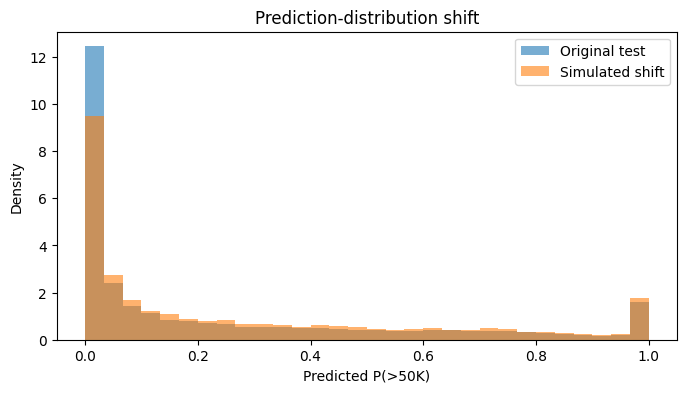

In [45]:
# Compare prediction distributions under the simulated input shift.
#
# We do NOT compute accuracy/F1 on shifted data because we did not create new
# ground-truth labels for the synthetic future population.
shifted_probabilities = best_model.predict_proba(X_shifted)[:, 1]

print(
    "Mean P(>50K), original test:",
    round(float(test_probabilities.mean()), 4),
)
print(
    "Mean P(>50K), shifted population:",
    round(float(shifted_probabilities.mean()), 4),
)

plt.figure(figsize=(8, 4))
plt.hist(
    test_probabilities,
    bins=30,
    alpha=0.6,
    density=True,
    label="Original test",
)
plt.hist(
    shifted_probabilities,
    bins=30,
    alpha=0.6,
    density=True,
    label="Simulated shift",
)
plt.xlabel("Predicted P(>50K)")
plt.ylabel("Density")
plt.title("Prediction-distribution shift")
plt.legend()
plt.show()

## 24. Save the complete model artifact

In [46]:
import joblib

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

MODEL_PATH = ARTIFACT_DIR / "adult_income_pipeline.joblib"
METADATA_PATH = ARTIFACT_DIR / "model_metadata.json"

# Save the entire Pipeline so preprocessing is always applied exactly as trained.
joblib.dump(best_model, MODEL_PATH)

metadata = {
    "project": "Adult Income Classification",
    "random_state": RANDOM_STATE,
    "selected_threshold": float(selected_threshold),
    "target_definition": "1 = income >50K",
    "best_parameters": search.best_params_,
    "official_test_metrics": {
        key: float(value)
        for key, value in test_metrics.items()
    },
    "raw_input_features": X_dev_all.columns.tolist(),
}

with open(METADATA_PATH, "w") as file:
    json.dump(metadata, file, indent=2)

print("Saved:", MODEL_PATH)
print("Saved:", METADATA_PATH)

Saved: artifacts/adult_income_pipeline.joblib
Saved: artifacts/model_metadata.json


## 25. Reusable inference function

In [47]:
def predict_income_probability(
    fitted_pipeline,
    person_features,
    threshold,
):
    # Convert one dictionary into the same DataFrame interface used during training.
    row = pd.DataFrame([person_features])

    # The fitted Pipeline automatically applies imputation, scaling,
    # one-hot encoding, and the final classifier.
    probability = float(
        fitted_pipeline.predict_proba(row)[:, 1][0]
    )

    return {
        "probability_income_gt_50k": probability,
        "predicted_class": int(probability >= threshold),
        "threshold": threshold,
    }

# Demonstration using one actual test row.
sample_person = X_test.iloc[0].to_dict()

predict_income_probability(
    best_model,
    sample_person,
    selected_threshold,
)

{'probability_income_gt_50k': 0.0015922816237434745,
 'predicted_class': 0,
 'threshold': 0.4}

## 26. Research report


### Data
- development observations:
- official test observations:
- positive-class rate:
- missing-value pattern:

### Model comparison
- best validation/CV model:
- did Logistic Regression remain competitive?
- how did KNN compare with the earlier project?
- did Random Forest improve over the linear baseline?
- did tuned XGBoost materially improve PR-AUC?

### Final test results
- ROC-AUC:
- PR-AUC:
- Precision:
- Recall:
- F1:
- Accuracy:
- selected threshold:

### Statistical interpretation
- notable Logistic Regression odds ratios:
- confidence intervals:
- which effects are statistically significant?
- which are practically meaningful?

### Explainability
- top SHAP features:
- top permutation-importance features:
- do both methods broadly agree?

### Errors
- false positives:
- false negatives:
- common error patterns:

### Subgroup diagnostics
- groups with noticeably lower recall/F1/AUC:
- possible sample-size / prevalence explanations:
- limitations:

### Stability
- natural development-vs-test drift:
- simulated drift signals:
- change in prediction distribution:

### Limitations
- observational data does not establish causality
- the dataset is old
- subgroup metrics may be unstable for small groups
- sensitive attributes require careful handling
- statistical significance is not the same as practical importance
- research performance does not justify consequential real-world use